# data.mat 에 어떤 key 와 value로 값이 저장되어있는지 확인하기 

In [ ]:
import h5py
import numpy as np

with h5py.File('data.mat', 'r') as f: 
    for key in f.keys():
        val = f[key][:] 
        print(f"{key}: shape={val.shape}, dtype={val.dtype}")

In [40]:
import h5py
import numpy as np

with h5py.File('data.mat', 'r') as f: # data.mat 파일을 읽기 모드로 열고 f 라는 변수로 사용 
    for key in f.keys(): # f.keys() = 파일 안에 있는 데이터 이름 목록 
        val = f[key][:] # f[key] : 해당 이름의 데이터셋 접근, [:] 전체 데이터를 실제로 읽어서 numpy 배열로 가져옴  . [:] 전체 범위를 슬라이싱 하겠다
        print(f"{key}: shape={val.shape}, dtype={val.dtype}") # f" 문자열 {변수}"

sim_acceleration: shape=(1, 51), dtype=float64
sim_altitude: shape=(1, 51), dtype=float64
sim_altitude_sensor: shape=(1, 51), dtype=float64
sim_time: shape=(51, 1), dtype=float64
sim_total_steps: shape=(1, 1), dtype=float64
sim_true: shape=(3, 1), dtype=float64
sim_velocity: shape=(1, 51), dtype=float64


# 🔵 Practice 1 문제

## ■ 풀이 전략 (Implementation Strategy)

이번 문제는 data.mat에 저장된 데이터를 이용하여  
Least Square Estimation으로 초기 상태 (r0, v0, a0)를 추정한다.

---

### 1. 데이터 불러오기

- data.mat 파일에서 필요한 변수 추출
  - sim_time → 시간 t
  - sim_altitude_sensor → 측정값 y
  - sim_true → 실제 상태 (정답)

---

### 2. 데이터 전처리

- t를 (N,) 형태로 변환
- y를 (N,) 또는 (N,1) 형태로 정리

---

### 3. H 행렬 구성

각 시간 t에 대해 다음 형태로 구성:

[1, t, t^2/2]

→ 전체 데이터에 대해 쌓으면 H는 (N x 3) 행렬

---

### 4. Least Square 계산

다음 식을 이용하여 상태 추정:

x_hat = (H^T H)^(-1) H^T y

---

### 5. 추정 결과 확인

- x_hat = [r0_hat, v0_hat, a0_hat]

---

### 6. 오차 계산

- error = sim_true - x_hat

---

### 7. 결과 출력

- 추정값 출력
- 실제값과 비교
- 오차 출력

In [37]:
# =========================================
# 1️⃣ 라이브러리 불러오기
# =========================================
import h5py   # .mat 이 HDF5 기반이라서 파일을 읽기 위한 라이브러리 
import numpy as np 

# with를 안 쓰면 

f = h5py.File("data.mat", "r") # 이렇게 하면 파일을 열기만 하고 안 닫음 -> 안 닫으면 메모리 누수 등의 문제가 발생할 수 있음 
    
sim_time = f['sim_time']    # lazy loading 이라는 상태 <HDF5 dataset "sim_time": shape (51, 1), type "<f8">   hdf5 파일 안에 저장된 데이터 셋, 데이터 셋 이름은 sim_time 이고 51행 1열 짜리 이며, 8바이트 float 자료형이다 

print(sim_time) 


#im_time = f['sim_time'][:]   # [:] 전체 데이터를 실제로 가져와라 -> 2차원 배열 [[ 51행 1열 ]] 
#print(sim_time)

sim_altitude_sensor = f['sim_altitude_sensor'] # 파일 안에 sim_altitude_sensor 라는 데이터셋에 접근 
print(sim_altitude_sensor.shape)





<HDF5 dataset "sim_time": shape (51, 1), type "<f8">
(1, 51)


In [58]:
# =========================================
# 1️⃣ 라이브러리 불러오기
# =========================================
import h5py
import numpy as np


# =========================================
# 2️⃣ data.mat 파일에서 필요한 값 불러오기
# =========================================
with h5py.File('data.mat', 'r') as f:   # 원래 f = h5py.File("data.mat","r") 이러면 파일 열기만 하고 안 닫음 -> f.close() 를 붙여야함 그게 귀
    sim_time = f['sim_time'][:]                  # shape: (51, 1)  # h5py로 읽은 데이터에 [:] -> 데이터 셋 전체를 읽어서 numpy 배열로 변환한다
    sim_altitude_sensor = f['sim_altitude_sensor'][:]  # shape: (1, 51)
    sim_true = f['sim_true'][:]                  # shape: (3, 1)


# =========================================
# 3️⃣ 데이터 전처리
#    - 계산하기 편하도록 1차원 / 2차원 형태 정리
# =========================================
t = sim_time.flatten()                          # shape: (51,)    # flatten()은 다차원 배열을 1차원 배열로 바꿔주는 함수 
y = sim_altitude_sensor.flatten().reshape(-1, 1)  # shape: (51, 1) # # reshape(행,열) -1 이면 전체 원소 개수를 numpy가 자동으로 계산 됨 이게 N행 1열로 reshape 한다는 의미
# 이게 이미 1행 51열인데 이걸 51행 1열로 바꾸려고 ㅇㅇ
x_true = sim_true                # shape: (3, 1) 이건 이미 열 벡터로 되어있음 

N = len(t)


# =========================================
# 4️⃣ H 행렬 구성
#    각 행: [1, t, t^2 / 2]
# =========================================
H = np.zeros((N, 3)) # N행 3열 

for i in range(N):
    H[i, :] = [1, t[i], 0.5 * (t[i] ** 2)]


# =========================================
# 5️⃣ Least Square Estimation 계산
#    x_hat = (H^T H)^(-1) H^T y
# =========================================
HTH = H.T @ H
HTy = H.T @ y
x_hat = np.linalg.inv(HTH) @ HTy

# 연립방정식 풀이 처럼 Ax = b 에서 slove(A,b) 하면 풀 수 있음 
# 그래서 x_hat = np.linalg.solve(H.T @ H, H.T @ y) 이렇게도 폴 수 있음 

# =========================================
# 6️⃣ 추정 오차 계산
# =========================================
error = x_true - x_hat
abs_error = np.abs(error)


# =========================================
# 7️⃣ 결과 출력
# =========================================
print("\n=== True State (x_true) ===")
print(f"r0_true = {x_true[0,0]:.6f}")
print(f"v0_true = {x_true[1,0]:.6f}")
print(f"a0_true = {x_true[2,0]:.6f}")

print("\n=== Estimated State (x_hat) ===")
print(f"r0_hat = {x_hat[0,0]:.6f}") # f "문자열 {변수}" 문자열 안에 변수 값을 넣어서 출력 / :.6f (포맷팅) : 포맷 시작, .6 소수점 6자리, f float 형식 
print(f"v0_hat = {x_hat[1,0]:.6f}")
print(f"a0_hat = {x_hat[2,0]:.6f}")

print("\n===  estimation Error (x_true - x_hat) ===")
print(f"r0_error = {error[0,0]:.6f}")
print(f"v0_error = {error[1,0]:.6f}")
print(f"a0_error = {error[2,0]:.6f}")


=== True State (x_true) ===
r0_true = 180.000000
v0_true = -10.000000
a0_true = -9.806650

=== Estimated State (x_hat) ===
r0_hat = 180.000544
v0_hat = -9.988953
a0_hat = -9.813624

===  estimation Error (x_true - x_hat) ===
r0_error = -0.000544
v0_error = -0.011047
a0_error = 0.006974


# practice 2-1 풀이

In [ ]:
# =========================================
# 1️⃣ 라이브러리 불러오기
# =========================================
import h5py
import numpy as np


# =========================================
# 2️⃣ 데이터 불러오기
#    .mat 파일은 h5py로 열고, [:] 로 numpy 배열 변환
#    차원이 헷갈릴 땐 일단 .flatten()으로 1차원 통일
# =========================================
with h5py.File('data.mat', 'r') as f:
    t = f['sim_time'][:].flatten()              # 시간     (N,)   그냥 1차원 배열이다 열벡터 행벡터 구분이 없음 shape 이 꼬이는 걸 방지하기 위해 전부 1차원으로 맞춰줬다 
    # 행렬 연산 및 element-wise 계산 과정에서 shape 불일치로 인한 broadcasting 오류를 방지하기 위해,
    # 시간 데이터와 측정 데이터를 1차원 배열 형태로 변환하였다.
    # broadcasting 오류 : 서로 다른 shape의 배열을 계산하려고 할 때 차원을 자동으로 맞추다가 실패하는 문제 
    y = f['sim_altitude_sensor'][:].flatten()   # 측정값   (N,)
    x_true = f['sim_true'][:].flatten()         # 참값     (3,)

N = len(t)


# =========================================
# 3️⃣ 측정 모델 → H 행렬 만들기
#    모델:   y = r0 + v0*t + (1/2)*a0*t^2 + noise
#    행렬형: y = H @ x,   x = [r0, v0, a0]^T
#    H의 한 행 = [1, t, 0.5*t^2]
# =========================================
# 재귀적이면 for문을 쓰고(prediction 했던 practice1 처럼) 아니면 stack 으로 한번에 행렬을 만들면 되는구나

# 측정 방정식 y = H @ x 가 51개의 스칼라 방정식을 묶은 것이고 
# H의 각 행이 그중 한 식의 계수(coefficient) 에 해당한다

H = np.column_stack([np.ones(N), t, 0.5 * t**2])  # column_stack 하면 1차원 배열을 받아서 자동으로 열벡터 취급해줌 


# =========================================
# 4️⃣ Least Square Estimation 계산
#    정규방정식: (H^T H) x_hat = H^T y
#    inv(...) @ ... 보다 solve가 안정적이고 빠름
# =========================================
x_hat = np.linalg.solve(H.T @ H, H.T @ y)


# =========================================
# 5️⃣ 결과 출력 (참값 / 추정값 / 오차)
# =========================================
print("x_true =", x_true)
print("x_hat  =", x_hat)
print("error  =", x_true - x_hat)

In [47]:
import h5py 
import numpy as np 

with h5py.File('data.mat', 'r') as f:
    sim_time = f['sim_time'][:]
    sim_altitude_sensor = f['sim_altitude_sensor'][:]
    sim_true = f['sim_true'][:]

# print(sim_true.shape)
# print(sim_time)    
t = sim_time.flatten() # 이건 2차원이라서 1차원으로 바꿈 
y = sim_altitude_sensor.flatten().reshape(51,1)
x_true = sim_true # 이미 열 벡터로 되어있음 이 친구는 

N = len(t)

H = np.zeros((N,3)) 

for i in range(N):
    H[i,:] = [1, t[i], 0.5*(t[i]**2)]

HTH = H.T @ H 
HTy = H.T @ y 
x_hat = np.linalg.inv(HTH) @ HTy

error = x_true - x_hat 

print(f"추정오차{error}")









추정오차[[-0.00054436]
 [-0.0110475 ]
 [ 0.00697367]]


# practice 2-2 풀이 

x_true = [180.      -10.       -9.80665]
x_hat  = [180.00054406  -9.98895226  -9.81362375]
error  = [-0.00054406 -0.01104774  0.00697375]


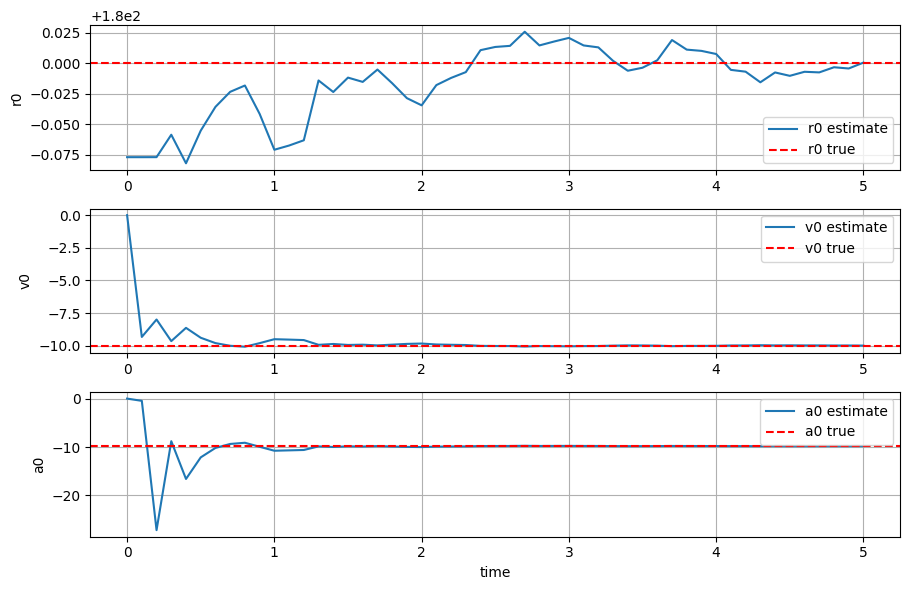

In [59]:
# =========================================
# 1️⃣ 라이브러리
# =========================================
import h5py
import numpy as np
import matplotlib.pyplot as plt


# =========================================
# 2️⃣ 데이터 불러오기 (Practice 1과 동일)
# =========================================
with h5py.File('data.mat', 'r') as f:
    t      = f['sim_time'][:].flatten()
    y      = f['sim_altitude_sensor'][:].flatten()
    x_true = f['sim_true'][:].flatten()

N = len(t)


# =========================================
# 3️⃣ RLS 초기화
#    x_hat: 추정값 [r0, v0, a0] → 모르니까 0으로 시작
#    P    : 추정 공분산 (불확실성). 처음엔 매우 크게(=잘 모름)
#    R    : 측정 노이즈 분산. 문제에서 noise ~ N(0, 0.01)
# =========================================
x_hat = np.zeros(3)              # (3,)
P     = np.eye(3) * 1e6 # 10의 6승이여서 1,000,000          # (3,3), 큰 값 = 초기 추정 신뢰도 낮음
R     = 0.01                     # 스칼라 (측정값이 1개씩 들어오므로) 이거 innovation 공분산에 쓰임 ㅇㅇ

# 시간에 따른 추정값 저장용 (plot에 사용)
x_history = np.zeros((N, 3))    # k = 0 ~ n-1 까지 저장 


# =========================================
# 4️⃣ RLS 루프
#    매 시점 k마다:
#      H_k : 1×3 행벡터  [1, t_k, 0.5*t_k^2]
#      K_k : Kalman gain (3×1)
#      x   : x + K(y_k - H_k x)        ← 새 측정으로 보정
#      P   : (I - K H_k) P              ← 불확실성 감소
# =========================================
for k in range(N):
    H_k = np.array([[1.0, t[k], 0.5 * t[k]**2]])   # (1,3) 행벡터로 명시, t[k] 는 0, 0.1 0.2 등간격 시간 

    # Kalman gain: K = P H^T / (H P H^T + R)
    # H P H^T + R 은 스칼라(1×1) → 그냥 나눗셈 가능
    S = H_k @ P @ H_k.T + R                        # (1,1) innovation(측정값의 잔차 의 공분산 )
    K = (P @ H_k.T) / S                            # (3,1)

    # 추정값 업데이트
    innovation = y[k] - H_k @ x_hat                # (1,) 잔차
    x_hat = x_hat + (K.flatten() * innovation)     # (3,)   # k 2차원이여서 1차원으로 바꿔줘야함 

    # 공분산 업데이트
    P = (np.eye(3) - K @ H_k) @ P                  # (3,3)   # 가장 간단한 형태 

    x_history[k] = x_hat


# =========================================
# 5️⃣ 결과 출력 & Plot
# =========================================
print("x_true =", x_true)
print("x_hat  =", x_hat)
print("error  =", x_true - x_hat)

labels = ['r0', 'v0', 'a0']
plt.figure(figsize=(9, 6))
for i in range(3):
    plt.subplot(3, 1, i+1)
    plt.plot(t, x_history[:, i], label=f'{labels[i]} estimate')
    plt.axhline(x_true[i], color='r', linestyle='--', label=f'{labels[i]} true')
    plt.ylabel(labels[i]); plt.legend(); plt.grid()
plt.xlabel('time')
plt.tight_layout()
plt.show()

In [ ]:
import h5py 
import numpy as np 
import matplotlib.pyplot as plt 

with h5py.File('data.mat', 'r') as f:
    t = f['sim_time'][:].flatten()
    y = f['sim_altitude_sensor'][:].flatten()
    x_true = f['sim_true'][:].flatten()
    
N = len(t)

x_hat = np.zeros(3)
P = np.eye(3)
R = 0.01 

x_